In [12]:
from langgraph.graph import StateGraph, START, END
from langchain_huggingface import HuggingFaceEndpoint, ChatHuggingFace
from dotenv import load_dotenv; load_dotenv()
import os
from typing import TypedDict, Literal, Annotated
from langchain_core.messages import SystemMessage, HumanMessage

In [13]:
llm = HuggingFaceEndpoint(
    repo_id="deepseek-ai/DeepSeek-R1",
    task="text-generation",
    huggingfacehub_api_token=os.getenv('HF_TOKEN')
)
gen_model = ChatHuggingFace(llm=llm)
eval_model = ChatHuggingFace(llm=llm)
opt_model = ChatHuggingFace(llm=llm)

In [14]:
from pydantic import BaseModel, Field

class TweetEvaluation(BaseModel):
    evaluation: Literal["approved", "improve"] = Field(..., description="Final evaluation result.")
    feedback: str = Field(..., description="feedback for the tweet.")

In [15]:
structured_eval_model = eval_model.with_structured_output(TweetEvaluation, method='json_schema')

In [16]:
class TweetState(TypedDict):

    topic: str
    tweet: str
    eval: Literal['approved', 'improve']
    feedback: str
    iteration: int
    max_itr: int

In [17]:
graph = StateGraph(TweetState)

In [18]:
def generate_tweet(state: TweetState):

    # prompt
    messages = [
        SystemMessage(content="You are a funny and clever Twitter/X influencer."),
        HumanMessage(content=f"""
Write a short, original, and hilarious tweet on the topic: "{state['topic']}".

Rules:
- Do NOT use question-answer format.
- Max 280 characters.
- Use observational humor, irony, sarcasm, or cultural references.
- Think in meme logic, punchlines, or relatable takes.
- Use simple, day to day english
""")
    ]
    response = gen_model.invoke(messages).content

    return {'tweet': response}

def evaluate_tweet(state: TweetState):

    messages = [
    SystemMessage(content="You are a ruthless, no-laugh-given Twitter critic. You evaluate tweets based on humor, originality, virality, and tweet format."),
    HumanMessage(content=f"""
Evaluate the following tweet:

Tweet: "{state['tweet']}"

Use the criteria below to evaluate the tweet:

1. Originality – Is this fresh, or have you seen it a hundred times before?  
2. Humor – Did it genuinely make you smile, laugh, or chuckle?  
3. Punchiness – Is it short, sharp, and scroll-stopping?  
4. Virality Potential – Would people retweet or share it?  
5. Format – Is it a well-formed tweet (not a setup-punchline joke, not a Q&A joke, and under 280 characters)?

Auto-reject if:
- It's written in question-answer format (e.g., "Why did..." or "What happens when...")
- It exceeds 280 characters
- It reads like a traditional setup-punchline joke
- Dont end with generic, throwaway, or deflating lines that weaken the humor (e.g., “Masterpieces of the auntie-uncle universe” or vague summaries)

### Respond ONLY in structured format:
- evaluation: "approved" or "needs_improvement"  
- feedback: One paragraph explaining the strengths and weaknesses 
""")
    ]
    response = structured_eval_model.invoke(messages)

    return {'eval': response['evaluation'], 'feedback': response['feedback']}

def optimize_tweet(state: TweetState):

    messages = [
        SystemMessage(content="You punch up tweets for virality and humor based on given feedback."),
        HumanMessage(content=f"""
Improve the tweet based on this feedback:
"{state['feedback']}"

Topic: "{state['topic']}"
Original Tweet:
{state['tweet']}

Re-write it as a short, viral-worthy tweet. Avoid Q&A style and stay under 280 characters.
""")
    ]
    response = opt_model.invoke(messages).content
    iteration = state['iteration'] + 1

    return {'tweet': response, 'iteration': iteration}

In [19]:
def route_evaluation(state: TweetState):

    if state['eval'] == 'approved' or state['iteration'] >= state['max_itr']:
        return 'approved'
    else:
        return 'improve' 

In [20]:
graph.add_node('generate', generate_tweet)
graph.add_node('evaluate', evaluate_tweet)
graph.add_node('optimize', optimize_tweet)

In [21]:
graph.add_edge(START, 'generate')
graph.add_edge('generate', 'evaluate')
graph.add_conditional_edges('evaluate', route_evaluation, {'approved': END, 'improve': 'optimize'})
graph.add_edge('optimize', 'evaluate')

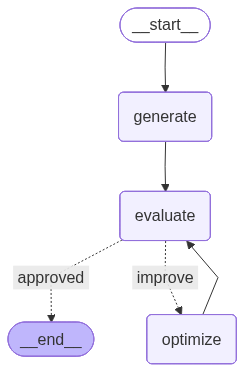

In [22]:
workflow = graph.compile()
workflow

In [23]:
initial_state = {
    "topic": "srhberhb",
    "iteration": 1,
    "max_iteration": 5
}
workflow.invoke(initial_state)

{'topic': 'srhberhb',
 'tweet': '\nJust tried to type "seriously" but my fingers did that thing cats do when they walk across your keyboard. Sent "srhberhb" to my boss. Oof. \n\n\\#AutocorrectFail \\#Relatable \\#KeyboardSmash',
 'eval': 'approved',
 'feedback': "The tweet's strength lies in its relatable humor, as the autocorrect mishap and cat keyboard analogy are likely to evoke a chuckle from anyone who's experienced typing errors, boosting its virality potential through hashtags like #Relatable and #AutocorrectFail. However, its originality is low since the concept of keyboard smashes and cat comparisons is overused, and the abrupt 'Oof.' ending feels a bit deflating, slightly undermining the punchiness despite the concise format.",
 'iteration': 1}